In [4]:
!pip install seaborn
!pip install torch
!pip install torchvision

     |████████████████████████████████| 292 kB 18.0 MB/s eta 0:00:01
     |████████████████████████████████| 9.5 MB 34.9 MB/s eta 0:00:01
     |████████████████████████████████| 25.9 MB 132 kB/s  eta 0:00:01
     |████████████████████████████████| 509 kB 35.8 MB/s eta 0:00:01
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
     |████████████████████████████████| 881.9 MB 10 kB/s s eta 0:00:01
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.
     |████████████████████████████████| 23.3 MB 18.0 MB/s eta 0:00:01
     |████████████████████████████████| 881.9 MB 8.4 kB/s  eta 0:00:01
  Attempting uninstall: torch
    Found existing installation: torch 1.10.2
    Uninstalling torch-1.10.2:
      Successfully uninstalled torch-1.10.2
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [5]:
!pip install scikit-learn

     |████████████████████████████████| 22.2 MB 16.3 MB/s eta 0:00:01
     |████████████████████████████████| 309 kB 38.4 MB/s eta 0:00:01
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [6]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import h5py

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 4
num_epochs = 20
learning_rate = 1e-5
sequence_length = 5

In [8]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [9]:
class CustomSingleFrameDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.class_to_idx = {
            cls_name: i for i, cls_name in enumerate(
                sorted([d for d in os.listdir(root_dir) if not d.startswith('.')])
            )
        }

        for class_name in sorted(os.listdir(root_dir)):
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            for fname in os.listdir(class_dir):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(class_dir, fname), self.class_to_idx[class_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_path, label = self.samples[idx]
        image = Image.open(frame_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


In [10]:
train_dataset = CustomSingleFrameDataset('./face_extraction/faceforensis_face_extract/train', transform=transform)
val_dataset   = CustomSingleFrameDataset('./face_extraction/faceforensis_face_extract/val', transform=transform)
test_dataset  = CustomSingleFrameDataset('./face_extraction/faceforensis_face_extract/test', transform=transform)


In [19]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

In [20]:
num_classes = len(train_dataset.class_to_idx)
print("Classes encontradas:", train_dataset.class_to_idx)

Classes encontradas: {'DeepFakeDetection': 0, 'FaceShifter': 1, 'FaceSwap': 2, 'NeuraTextures': 3, 'deepfakes': 4, 'face2face': 5, 'original': 6}


In [13]:
!pip install timm

     |████████████████████████████████| 549 kB 15.4 MB/s eta 0:00:01
     |████████████████████████████████| 67 kB 960 kB/s  eta 0:00:01
     |████████████████████████████████| 677 kB 54.5 MB/s eta 0:00:01
     |████████████████████████████████| 40 kB 938 kB/s  eta 0:00:01
     |████████████████████████████████| 78 kB 1.5 MB/s  eta 0:00:01
  Attempting uninstall: packaging
    Found existing installation: packaging 20.8
    Uninstalling packaging-20.8:
      Successfully uninstalled packaging-20.8
You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [14]:
!pip install timm

You should consider upgrading via the '/usr/bin/python3 -m pip install --upgrade pip' command.


In [15]:
import timm
model = timm.create_model('convnext_base', pretrained=True)

Downloading: "https://dl.fbaipublicfiles.com/convnext/convnext_base_1k_224_ema.pth" to /root/.cache/torch/hub/checkpoints/convnext_base_1k_224_ema.pth


In [21]:
class ConvNeXtSingleFrame(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base_model = timm.create_model('convnext_base', pretrained=True, num_classes=0)  # remove head
        self.backbone = base_model
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.backbone(x)            # shape: [B, 1024]
        x = self.dropout(x)             # shape: [B, 1024]
        return self.fc(x)               # shape: [B, num_classes]
    
model = ConvNeXtSingleFrame(num_classes=num_classes).to(device)

In [22]:
def calculate_accuracy(outputs, targets):
    _, preds = torch.max(outputs, 1)
    return (preds == targets).float().mean().item()

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    best_accuracy = 0.0
    start_time = time.time()

    for epoch in range(num_epochs):
        model.train()
        running_loss, running_acc = 0.0, 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            acc = calculate_accuracy(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_acc += acc * inputs.size(0)

            del inputs, labels, outputs, loss
            torch.cuda.empty_cache()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_acc / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validação
        model.eval()
        val_running_loss, val_running_acc = 0.0, 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                acc = calculate_accuracy(outputs, labels)
                val_running_loss += loss.item() * inputs.size(0)
                val_running_acc += acc * inputs.size(0)

                del inputs, labels, outputs, loss
                torch.cuda.empty_cache()

        val_epoch_loss = val_running_loss / len(val_loader.dataset)
        val_epoch_acc = val_running_acc / len(val_loader.dataset)
        val_losses.append(val_epoch_loss)
        val_accuracies.append(val_epoch_acc)

        print(f'Epoch {epoch+1}/{num_epochs}, '
              f'Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, '
              f'Val Loss: {val_epoch_loss:.4f}, Val Acc: {val_epoch_acc:.4f}')

        if val_epoch_acc > best_accuracy:
            best_accuracy = val_epoch_acc
            torch.save(model.state_dict(), 'best_model.pth')

    total_time = time.time() - start_time
    print(f'Training complete in {total_time // 60:.0f}m {total_time % 60:.0f}s')
    return train_losses, val_losses, train_accuracies, val_accuracies

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
train_losses, val_losses, train_accuracies, val_accuracies = train_model(
    model, train_loader, val_loader, criterion, optimizer, num_epochs
)

Epoch 1/20, Train Loss: 0.6029, Train Acc: 0.7903, Val Loss: 0.2828, Val Acc: 0.8968
Epoch 2/20, Train Loss: 0.1938, Train Acc: 0.9360, Val Loss: 0.2345, Val Acc: 0.9177
Epoch 3/20, Train Loss: 0.1262, Train Acc: 0.9571, Val Loss: 0.2365, Val Acc: 0.9200
Epoch 4/20, Train Loss: 0.0929, Train Acc: 0.9684, Val Loss: 0.2490, Val Acc: 0.9185
Epoch 5/20, Train Loss: 0.0703, Train Acc: 0.9766, Val Loss: 0.2514, Val Acc: 0.9257
Epoch 6/20, Train Loss: 0.0556, Train Acc: 0.9810, Val Loss: 0.4649, Val Acc: 0.8783
Epoch 7/20, Train Loss: 0.0436, Train Acc: 0.9853, Val Loss: 0.3102, Val Acc: 0.9200
Epoch 8/20, Train Loss: 0.0350, Train Acc: 0.9882, Val Loss: 0.2842, Val Acc: 0.9300
Epoch 9/20, Train Loss: 0.0286, Train Acc: 0.9909, Val Loss: 0.3392, Val Acc: 0.9211
Epoch 10/20, Train Loss: 0.0222, Train Acc: 0.9935, Val Loss: 0.4348, Val Acc: 0.9091
Epoch 11/20, Train Loss: 0.0209, Train Acc: 0.9944, Val Loss: 0.3797, Val Acc: 0.9160
Epoch 12/20, Train Loss: 0.0182, Train Acc: 0.9949, Val Loss: 0

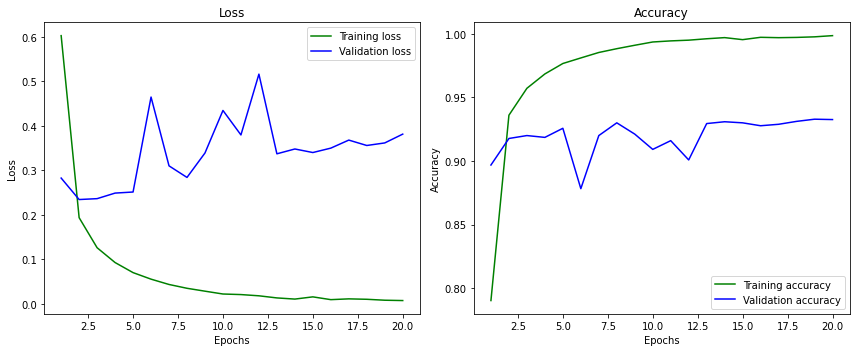

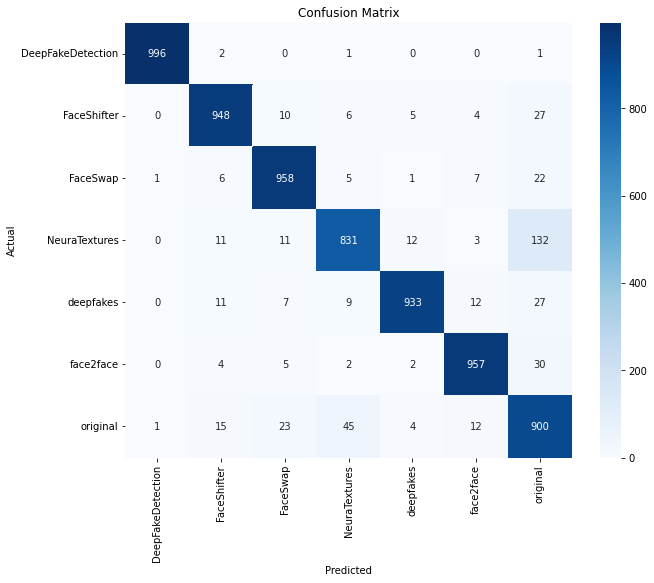

In [24]:
# Graphs
epochs = range(1, num_epochs + 1)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'g', label='Training loss')
plt.plot(epochs, val_losses, 'b', label='Validation loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, 'g', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'b', label='Validation accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Evaluation
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=list(train_dataset.class_to_idx.keys()), yticklabels=list(train_dataset.class_to_idx.keys()), cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [25]:
from sklearn.metrics import f1_score, roc_auc_score, classification_report

# Verifique se precisa das probabilidades para o AUC
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# F1-score (macro)
f1 = f1_score(all_labels, all_preds, average='macro')

# Acurácia geral
acc = np.mean(np.array(all_preds) == np.array(all_labels))

# Relatório por classe
report = classification_report(all_labels, all_preds, target_names=list(train_dataset.class_to_idx.keys()), zero_division=0)
print("\nClassification Report:\n", report)

# Métricas globais
print(f"\nFinal Evaluation:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  F1-score:  {f1:.4f}")



Classification Report:
                    precision    recall  f1-score   support

DeepFakeDetection       1.00      1.00      1.00      2000
      FaceShifter       0.95      0.95      0.95      2000
         FaceSwap       0.94      0.96      0.95      2000
    NeuraTextures       0.92      0.83      0.88      2000
        deepfakes       0.97      0.93      0.95      1998
        face2face       0.96      0.96      0.96      2000
         original       0.79      0.90      0.84      2000

         accuracy                           0.93     13998
        macro avg       0.93      0.93      0.93     13998
     weighted avg       0.93      0.93      0.93     13998


Final Evaluation:
  Accuracy:  0.9320
  F1-score:  0.9326


In [26]:
def save_model_to_h5(model, filename):
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224).to(device)  # apenas 1 frame
    traced_model = torch.jit.trace(model, dummy_input)
    traced_model.save('temp_model.pt')
    with open('temp_model.pt', 'rb') as f:
        buffer = f.read()
    with h5py.File(filename, 'w') as h5f:
        h5f.create_dataset('model', data=np.void(buffer))
    os.remove('temp_model.pt')


In [27]:
import torch
import h5py
import numpy as np
import os

def save_model_to_h5(model, filename="best_model_convnext_v2.h5"):
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224).to(next(model.parameters()).device)

    # Traçar o modelo com TorchScript
    traced_model = torch.jit.trace(model, dummy_input)

    # Salvar temporariamente como .pt
    temp_path = "temp_model.pt"
    traced_model.save(temp_path)

    # Ler bytes do .pt e armazenar no HDF5
    with open(temp_path, 'rb') as f:
        buffer = f.read()
    with h5py.File(filename, 'w') as h5f:
        h5f.create_dataset('model', data=np.void(buffer))

    # Remover temporário
    os.remove(temp_path)

    print(f"Modelo salvo como '{filename}' (HDF5 contendo TorchScript).")


In [29]:
def save_model_to_h5(model, filename):
    model.eval()
    dummy_input = torch.randn(1, 3, 224, 224).to(device)  # 4D para CNN
    traced_model = torch.jit.trace(model, dummy_input)
    traced_model.save('temp_model.pt')
    with open('temp_model.pt', 'rb') as f:
        buffer = f.read()
    with h5py.File(filename, 'w') as h5f:
        h5f.create_dataset('model', data=np.void(buffer))
    os.remove('temp_model.pt')
